Dataset: c:\Users\Lenovo\OneDrive\Desktop\data-science-playground\data-science-playground\data-science-playground\Machine-Learning-Lab\data\Salary_data.csv
Training records: 8
Test records: 2
MAE: $20,125.00
MSE: 717,421,250.00
RMSE: $26,784.72
R2 Score: 0.9858


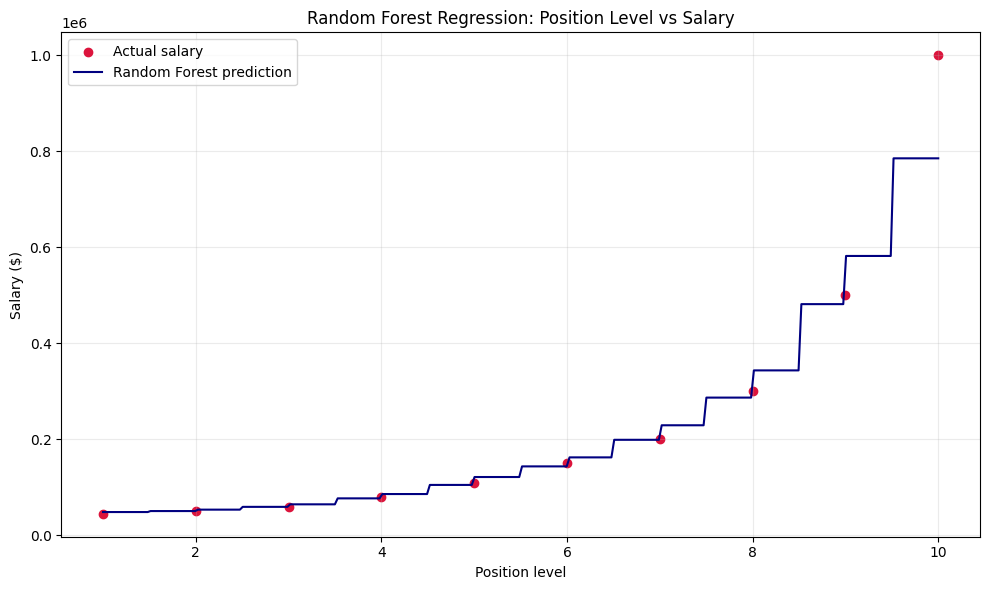

Predicted salary for level 6.5: $162,500.00


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


def find_data_file() -> Path:
    notebook_dir = Path.cwd()
    candidates = (
        notebook_dir / "data" / "Salary_data.csv",
        notebook_dir / "Machine-Learning-Lab" / "data" / "Salary_data.csv",
        notebook_dir.parent / "data" / "Salary_data.csv",
        notebook_dir.parent.parent / "data" / "Salary_data.csv",
    )

    for candidate in candidates:
        if candidate.is_file():
            return candidate

    expected_path = candidates[0]
    raise FileNotFoundError(
        f"Could not find Salary_data.csv. Expected it under: {expected_path}"
    )


data_path = find_data_file()
df = pd.read_csv(data_path)
required_columns = {"Position", "Level", "Salary"}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Salary_data.csv is missing required columns: {sorted(missing_columns)}"
    )

if df.empty:
    raise ValueError("Salary_data.csv does not contain any records.")

X = df[["Level"]].apply(pd.to_numeric, errors="raise")
y = pd.to_numeric(df["Salary"], errors="raise")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

evaluation_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
)
evaluation_model.fit(X_train, y_train)
y_pred = evaluation_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Dataset: {data_path}")
print(f"Training records: {len(X_train)}")
print(f"Test records: {len(X_test)}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: ${np.sqrt(mse):,.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
)
model.fit(X, y)

plot_levels = np.linspace(X["Level"].min(), X["Level"].max(), 300)
plot_predictions = model.predict(pd.DataFrame({"Level": plot_levels}))

plt.figure(figsize=(10, 6))
plt.scatter(X["Level"], y, color="crimson", label="Actual salary")
plt.plot(plot_levels, plot_predictions, color="navy", label="Random Forest prediction")
plt.title("Random Forest Regression: Position Level vs Salary")
plt.xlabel("Position level")
plt.ylabel("Salary ($)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

custom_level = 6.5
custom_prediction = model.predict(pd.DataFrame({"Level": [custom_level]}))[0]
print(f"Predicted salary for level {custom_level}: ${custom_prediction:,.2f}")